In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

In [2]:


# 1. Define the directory path
folder_path = Path("../dataset/dsfsi-anv/anv")

# 2. Get all CSV files in the folder (use rglob("*.csv") to include subfolders)
csv_files = list(folder_path.glob("*.csv"))

In [3]:
df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

In [4]:
df.shape

(459355, 22)

In [5]:
df.head(5)

,language,split,audio_id,recorder_uuid,type,system_file_name,file_name,full_path,domain,topic,...,duration,size_bytes,microphone_device_id,microphone_label,signal_to_noise_ratio,document_id,source_document,audio_sampling_rate,audio_num_samples,audio_num_channels
0,ZUL,dev,ZUL-1b8993dd-19c2-11f0-9933-0242ac120005-SCR-A...,1b8993dd-19c2-11f0-9933-0242ac120005,scripted,recording-1746103066.wav,ZUL-1b8993dd-19c2-11f0-9933-0242ac120005-SCR-A...,audio/ZUL/1b8993dd-19c2-11f0-9933-0242ac120005...,Agriculture,Support,...,20.112917,1930918,044f9eeec1604d95e06dd078981be0545bd1e27fcfca2a...,Microphone (Realtek(R) Audio),38.25,pula-imvula-6bd29e72-e279-4e73-85f5-d4832a59c65c,Pula_imvula,48000,965420,1
1,ZUL,dev,ZUL-1b8993dd-19c2-11f0-9933-0242ac120005-SCR-A...,1b8993dd-19c2-11f0-9933-0242ac120005,scripted,recording-1746105247.wav,ZUL-1b8993dd-19c2-11f0-9933-0242ac120005-SCR-A...,audio/ZUL/1b8993dd-19c2-11f0-9933-0242ac120005...,Agriculture,Fertility,...,12.625771,1212152,044f9eeec1604d95e06dd078981be0545bd1e27fcfca2a...,Microphone (Realtek(R) Audio),30.25,pula-imvula-7f9354e5-3e56-4f2c-b839-b8b7212738c5,Pula_imvula,48000,606037,1
2,ZUL,dev,ZUL-1b8993dd-19c2-11f0-9933-0242ac120005-SCR-A...,1b8993dd-19c2-11f0-9933-0242ac120005,scripted,recording-1746105379.wav,ZUL-1b8993dd-19c2-11f0-9933-0242ac120005-SCR-A...,audio/ZUL/1b8993dd-19c2-11f0-9933-0242ac120005...,Agriculture,Storage,...,10.900646,1046540,044f9eeec1604d95e06dd078981be0545bd1e27fcfca2a...,Microphone (Realtek(R) Audio),30.25,pula-imvula-10f3e149-ac3b-47e8-80f0-42ae959709ad,Pula_imvula,48000,523231,1
3,ZUL,dev,ZUL-1b8993dd-19c2-11f0-9933-0242ac120005-SCR-A...,1b8993dd-19c2-11f0-9933-0242ac120005,scripted,recording-1746105918.wav,ZUL-1b8993dd-19c2-11f0-9933-0242ac120005-SCR-A...,audio/ZUL/1b8993dd-19c2-11f0-9933-0242ac120005...,Agriculture,Support,...,15.425250,1480902,044f9eeec1604d95e06dd078981be0545bd1e27fcfca2a...,Microphone (Realtek(R) Audio),30.25,pula-imvula-71ad058a-07d0-4559-ac3f-31c327140d3a,Pula_imvula,48000,740412,1
4,ZUL,dev,ZUL-1b8993dd-19c2-11f0-9933-0242ac120005-SCR-G...,1b8993dd-19c2-11f0-9933-0242ac120005,scripted,recording-1746339160.wav,ZUL-1b8993dd-19c2-11f0-9933-0242ac120005-SCR-G...,audio/ZUL/1b8993dd-19c2-11f0-9933-0242ac120005...,General,Leadership,...,11.205917,1075846,044f9eeec1604d95e06dd078981be0545bd1e27fcfca2a...,Microphone (Realtek(R) Audio),32.59,wiki-982aecc5-a910-422d-85f3-510a2668fe36,Wikipedia,48000,537884,1


In [6]:
df = df.astype({"language":'category',"split":'category','audio_id':'string','recorder_uuid':'string'},)
df = df.astype({'type':'category','domain':'category','topic':'category',})
df = df.astype({'scenario':'string','transcript':'string','document_id':'string','source_document':'category'})
df = df.astype({'microphone_device_id':'string','microphone_label':'category'})

In [7]:
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 459355 entries, 0 to 459354
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   language               459355 non-null  category
 1   split                  459355 non-null  category
 2   audio_id               459355 non-null  string  
 3   recorder_uuid          459355 non-null  string  
 4   type                   459355 non-null  category
 5   system_file_name       459355 non-null  object  
 6   file_name              459355 non-null  object  
 7   full_path              459355 non-null  object  
 8   domain                 459355 non-null  category
 9   topic                  459355 non-null  category
 10  scenario               401475 non-null  string  
 11  transcript             459283 non-null  string  
 12  duration               459355 non-null  float64 
 13  size_bytes             459355 non-null  int64   
 14  microphone_device_id

In [8]:
df.isnull().sum()

language                      0
split                         0
audio_id                      0
recorder_uuid                 0
type                          0
system_file_name              0
file_name                     0
full_path                     0
domain                        0
topic                         0
scenario                  57880
transcript                   72
duration                      0
size_bytes                    0
microphone_device_id          0
microphone_label              0
signal_to_noise_ratio         0
document_id              271794
source_document          271794
audio_sampling_rate           0
audio_num_samples             0
audio_num_channels            0
dtype: int64

In [9]:
drop_coloumns = ['system_file_name','file_name','full_path']
display(df.drop(columns=drop_coloumns).describe(include='all'))
#drop_coloums = ['langauge','system_file_name','file_name','full_path']

,language,split,audio_id,recorder_uuid,type,domain,topic,scenario,transcript,duration,size_bytes,microphone_device_id,microphone_label,signal_to_noise_ratio,document_id,source_document,audio_sampling_rate,audio_num_samples,audio_num_channels
count,459355,459355,459355,459355,459355,459355,459355,401475,459283,459355.000000,4.593550e+05,459355,459355,459355.000000,187561,187561,459355.0,4.593550e+05,459355.0
unique,7,3,459355,2214,2,11,3171,3092,353120,NaN,NaN,4328,318,NaN,4396,5,NaN,NaN,NaN
top,TSN,train,ZUL-1b8993dd-19c2-11f0-9933-0242ac120005-SCR-A...,9eb56c04-475b-11f0-bec8-0242ac120004,unscripted,General,Commuting,Commercial Crops,Botshelo jwa diritibatsi ke bo tlisitse mathat...,NaN,NaN,default,Default,NaN,wrdnt-24c1f75b-7028-488d-b1c1-594dcd41ecca,Vukuzenzele,NaN,NaN,NaN
freq,94601,411110,1,1158,271794,130558,22299,12738,281,NaN,NaN,177333,146954,NaN,34169,77882,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.425335,2.129073e+06,NaN,NaN,41.618833,NaN,NaN,48000.0,1.076445e+06,1.0
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.930525,1.538946e+06,NaN,NaN,9.939957,NaN,NaN,0.0,7.651738e+05,0.0
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.200000,1.927800e+04,NaN,NaN,30.000000,NaN,NaN,48000.0,9.600000e+03,1.0
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.515614,9.889310e+05,NaN,NaN,34.250000,NaN,NaN,48000.0,5.045680e+05,1.0
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.328000,1.734766e+06,NaN,NaN,39.270000,NaN,NaN,48000.0,8.796920e+05,1.0
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.855646,2.833381e+06,NaN,NaN,46.070000,NaN,NaN,48000.0,1.433144e+06,1.0


## Now viewing: **Language**

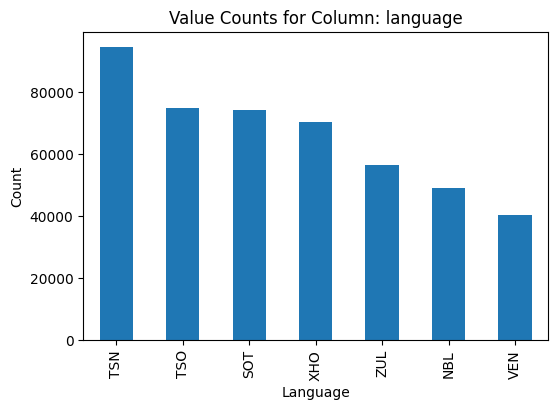

In [10]:
# Use display() combined with Markdown()
display(Markdown(f"## Now viewing: **Language**"))

plt.figure(figsize=(6, 4))
df['language'].value_counts().plot(kind="bar")
plt.title(f"Value Counts for Column: language")
plt.xlabel("Language")
plt.ylabel("Count")
plt.show()

In [11]:
languages = df['language'].unique()
languages

['ZUL', 'NBL', 'VEN', 'TSN', 'TSO', 'XHO', 'SOT']
Categories (7, object): ['NBL', 'SOT', 'TSN', 'TSO', 'VEN', 'XHO', 'ZUL']

In [12]:
# lang_dict = {
#     "isiNdebele": "NBL",
#     "isiXhosa": "XHO",
#     "isiZulu": "ZUL",
#     "Sesotho": "SOT",
#     "Setswana": "TSN",
#     "Tshivenda": "VEN",
#     "Xitsonga": "TSO",
# }

lang_dict = {
    "Setswana": "TSN",
    "Tshivenda": "VEN",
}

In [13]:
N = 2 #number of languages to display

## Now viewing Setswana (TSN): **split**

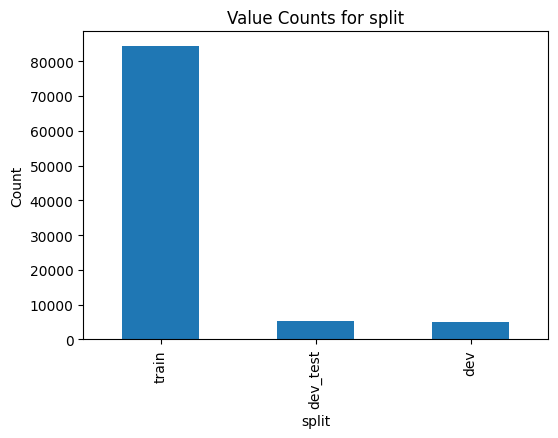

## Now viewing Setswana (TSN): **type**

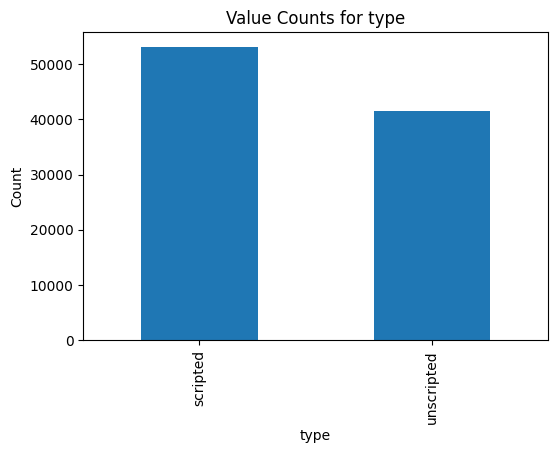

## Now viewing Setswana (TSN): **domain**

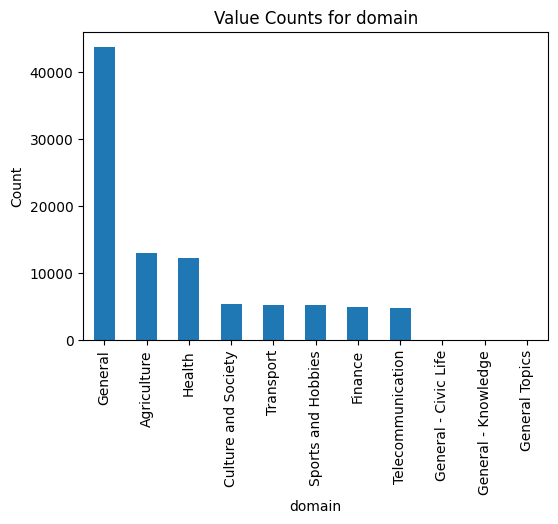

## Now viewing Setswana (TSN): **microphone_label**

/Users/mulisamusehane/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


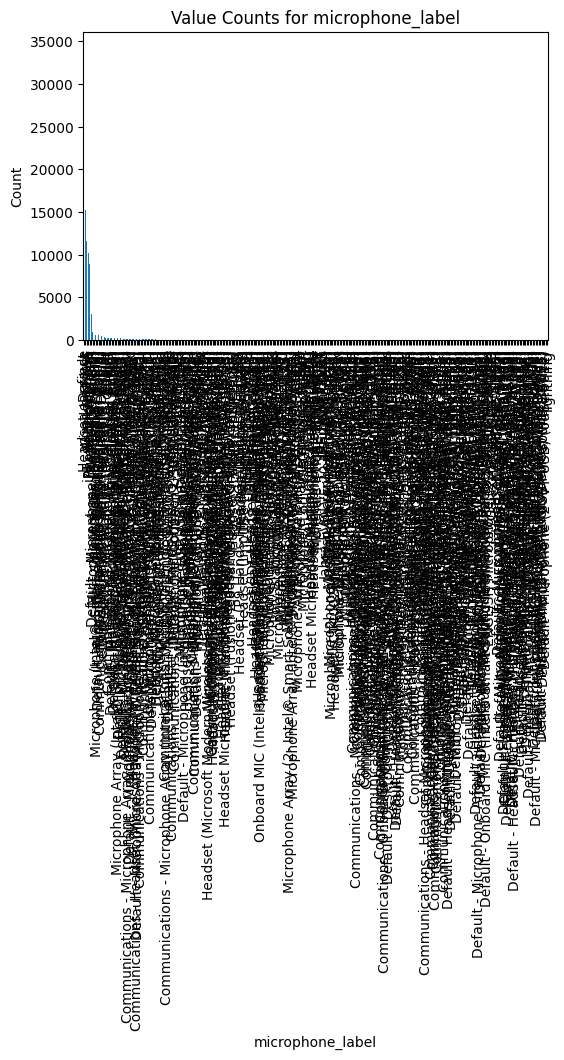

## Now viewing Setswana (TSN): **source_document**

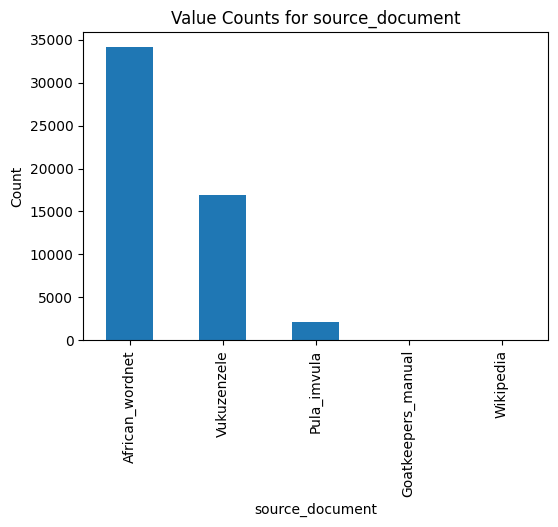

## Now viewing Tshivenda (VEN): **split**

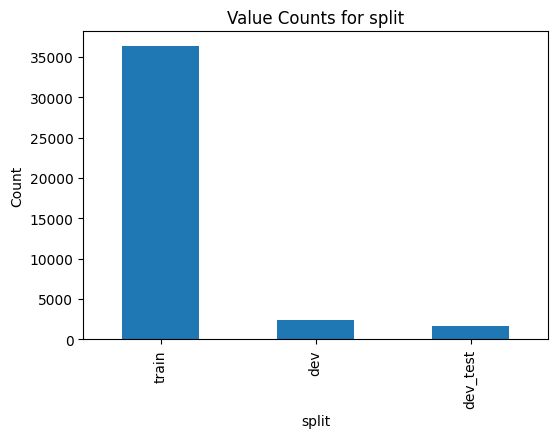

## Now viewing Tshivenda (VEN): **type**

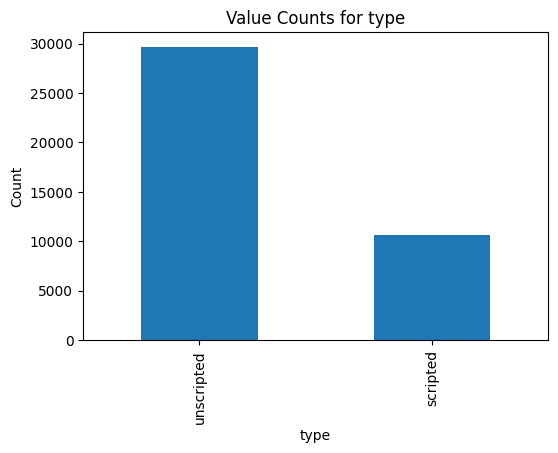

## Now viewing Tshivenda (VEN): **domain**

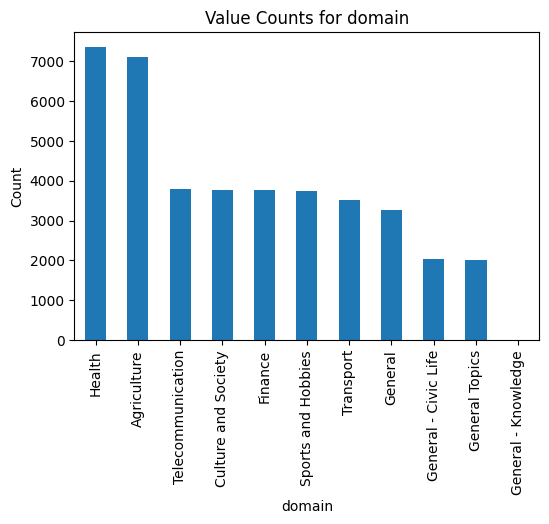

## Now viewing Tshivenda (VEN): **microphone_label**

/Users/mulisamusehane/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


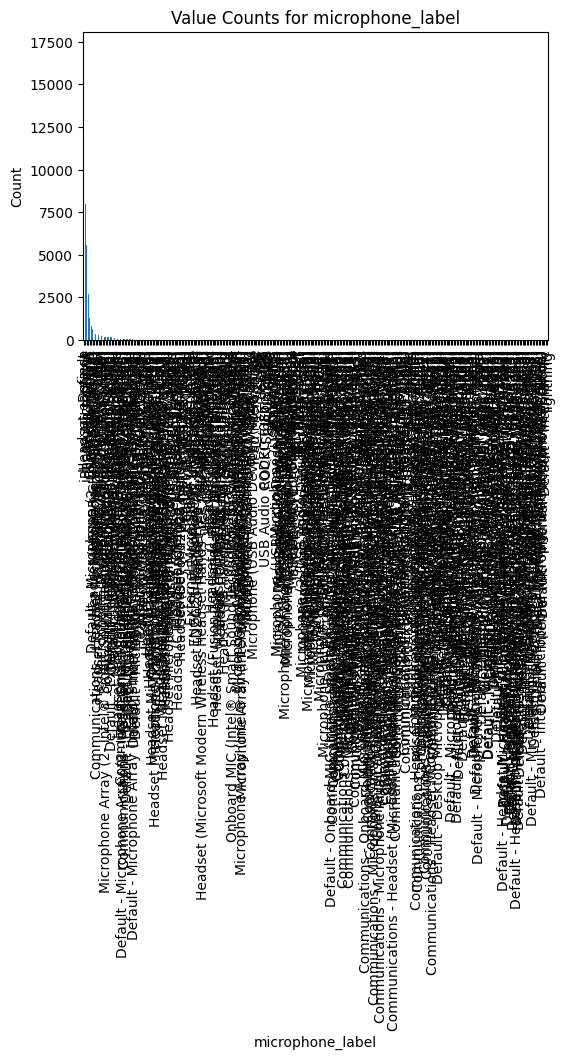

## Now viewing Tshivenda (VEN): **source_document**

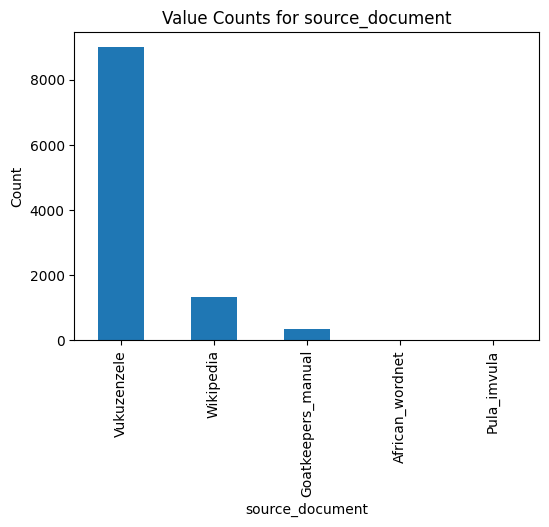

In [14]:
for language, code in list(lang_dict.items())[:N]:
    df_filtered = df[df['language'] == code]
    display_coloumns = ['split','type','domain','microphone_label', 'source_document']
    for col in df_filtered[display_coloumns].columns:
        # Use display() combined with Markdown()
        display(Markdown(f"## Now viewing {language} ({code}): **{col}**"))

        plt.figure(figsize=(6, 4))
        df_filtered[col].value_counts().plot(kind="bar")
        plt.title(f"Value Counts for {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()

## Now viewing: **duration**

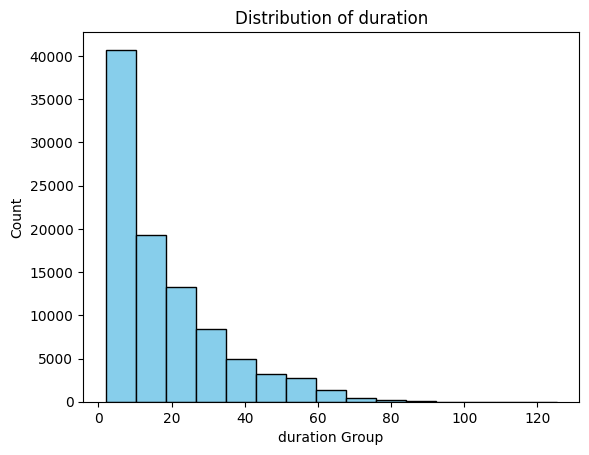

count    94601.000000
mean        18.131643
std         14.966598
min          2.009958
25%          6.713188
50%         12.594083
75%         24.917982
max        125.235604
Name: duration, dtype: float64

## Now viewing: **size_bytes**

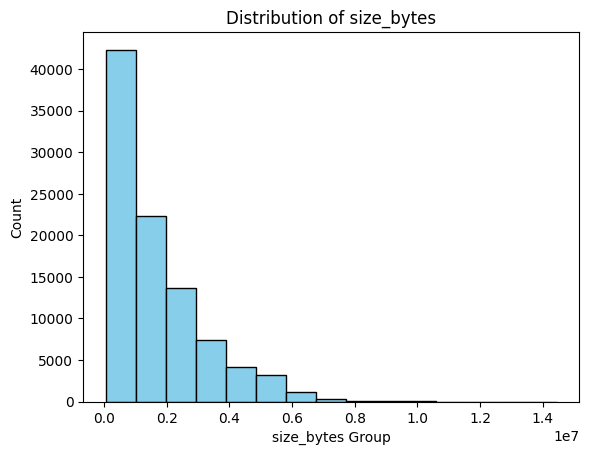

count    9.460100e+04
mean     1.712526e+06
std      1.423313e+06
min      5.334400e+04
25%      6.362040e+05
50%      1.187558e+06
75%      2.348520e+06
max      1.444405e+07
Name: size_bytes, dtype: float64

## Now viewing: **signal_to_noise_ratio**

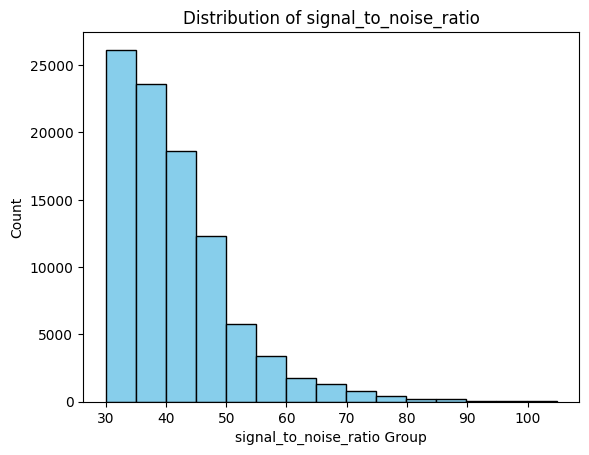

count    94601.000000
mean        41.493473
std          9.530972
min         30.000000
25%         34.440000
50%         39.490000
75%         45.790000
max        104.820000
Name: signal_to_noise_ratio, dtype: float64

## Now viewing: **audio_num_samples**

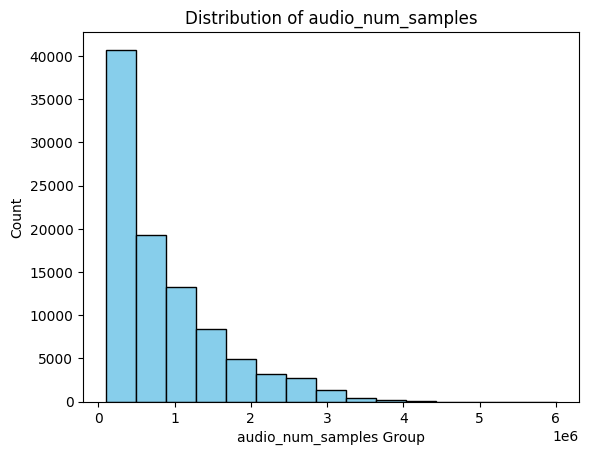

count    9.460100e+04
mean     8.703586e+05
std      7.184390e+05
min      9.647800e+04
25%      3.222330e+05
50%      6.045160e+05
75%      1.196111e+06
max      6.011309e+06
Name: audio_num_samples, dtype: float64

## Now viewing: **duration**

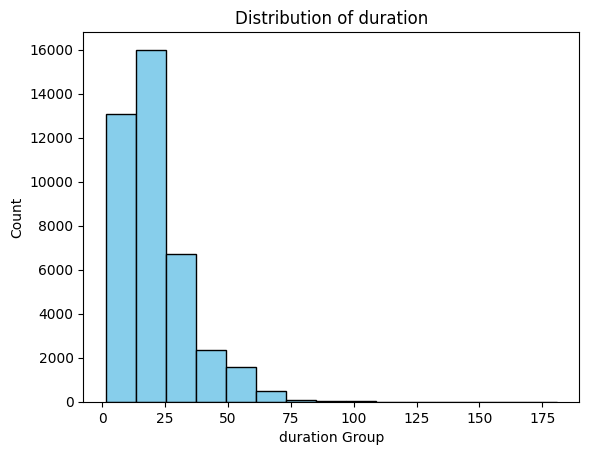

count    40359.000000
mean        21.265833
std         13.634551
min          1.474667
25%         11.913187
50%         17.666792
75%         26.916730
max        180.712125
Name: duration, dtype: float64

## Now viewing: **size_bytes**

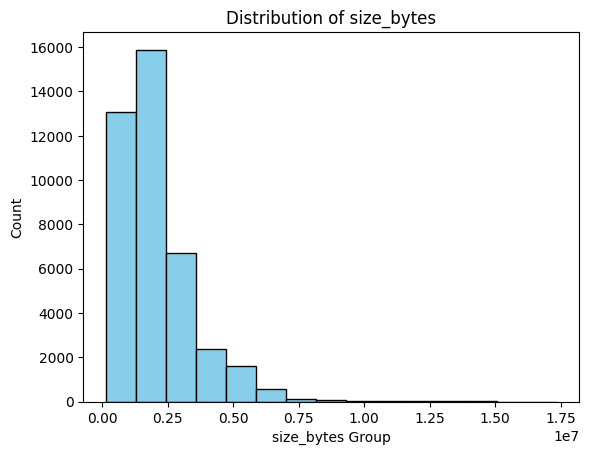

count    4.035900e+04
mean     2.054893e+06
std      1.364225e+06
min      1.346040e+05
25%      1.135323e+06
50%      1.694734e+06
75%      2.597527e+06
max      1.734844e+07
Name: size_bytes, dtype: float64

## Now viewing: **signal_to_noise_ratio**

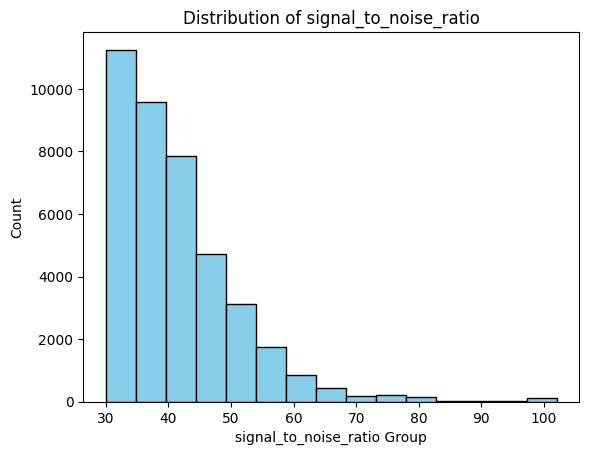

count    40359.000000
mean        41.439524
std          9.815613
min         30.000000
25%         34.130000
50%         39.190000
75%         45.920000
max        102.020000
Name: signal_to_noise_ratio, dtype: float64

## Now viewing: **audio_num_samples**

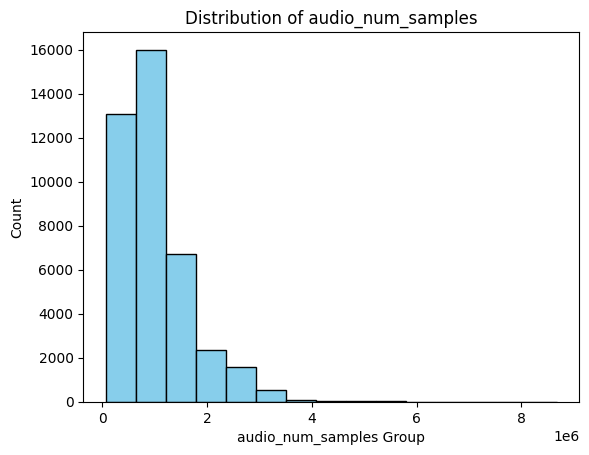

count    4.035900e+04
mean     1.020760e+06
std      6.544584e+05
min      7.078400e+04
25%      5.718330e+05
50%      8.480060e+05
75%      1.292003e+06
max      8.674182e+06
Name: audio_num_samples, dtype: float64

In [15]:
for language, code in list(lang_dict.items())[:N]:
    df_filtered = df[df['language'] == code]
    display_coloumns = ['duration','size_bytes','signal_to_noise_ratio','audio_num_samples']
    for col in df_filtered[display_coloumns].columns:

        display(Markdown(f"## Now viewing: **{col}**"))

        # Pass the data array/series directly
        plt.hist(df_filtered[col], bins=15, color="skyblue", edgecolor="black")

        # Adding labels
        plt.title(f"Distribution of {col}")
        plt.xlabel(f"{col} Group")
        plt.ylabel("Count")

        # Display the plot
        plt.show()

        display(df_filtered[col].describe())

In [16]:
# Tshivenda only - Setswana/Sepedi are handled by their own sub-studies
for language, code in [("Tshivenda", "VEN")]:
    df_filtered = df[df['language'] == code]

    display(Markdown(f"## Now viewing: **Data quality checks for {language} ({code})**"))

    display(Markdown(f"### Sampling rates: {df_filtered['audio_sampling_rate'].value_counts().to_dict()}"))
    display(Markdown(f"### Channels: {df_filtered['audio_num_channels'].value_counts().to_dict()}"))

    duplicate_audio_ids = df_filtered['audio_id'].duplicated().sum()
    display(Markdown(f"### Number of duplicate audio_ids: {duplicate_audio_ids}"))

    clips_under_1s = (df_filtered['duration'] < 1).sum()
    clips_under_5s = (df_filtered['duration'] < 5).sum()
    clips_over_30s = (df_filtered['duration'] > 30).sum()
    display(Markdown(f"### Clips < 1s: {clips_under_1s} | Clips < 5s: {clips_under_5s} | Clips > 30s: {clips_over_30s}"))

    snr_below_15 = (df_filtered['signal_to_noise_ratio'] < 15).sum()
    min_snr = df_filtered['signal_to_noise_ratio'].min()
    display(Markdown(f"### Clips with SNR < 15 dB: {snr_below_15} (min SNR = {min_snr:.1f} dB)"))

    recorders_in_multiple_splits = (df_filtered.groupby('recorder_uuid')['split'].nunique() > 1).sum()
    display(Markdown(f"### Recorders appearing in more than one split: {recorders_in_multiple_splits}"))

## Now viewing: **Data quality checks for Tshivenda (VEN)**

### Sampling rates: {48000: 40359}

### Channels: {1: 40359}

### Number of duplicate audio_ids: 0

### Clips < 1s: 0 | Clips < 5s: 1171 | Clips > 30s: 8028

### Clips with SNR < 15 dB: 0 (min SNR = 30.0 dB)

### Recorders appearing in more than one split: 0

# Transcript Analysis

## Now viewing: **Top words in Setswana (TSN)**

### Type: scripted

,type,transcript
145758,scripted,Go duela lekgetho go tlhokiwa ditlhankana tse dingwe morago ga ngwaga ya ditšhelete mme ga di kgonwe go dirisiwa go laola ditšhelete tsa go tsamaisa kgwebo ya gago.
145759,scripted,Phuthego e ne e beilwe go keteka nako le matsapa a setlhopha se a dirisitseng go tsweletse pele lenaneo la go bona balemirui ba ba ka tlhabololwang.
145760,scripted,Riseke ya kwelotlase ya thobo ya dijalo
145761,scripted,"Direšene tse di tswakilweng sekgwebo di siame thata e bile di lekalekana sesaense, fela di a tura."
145762,scripted,"Go ne go tshweufatsa pelo go utlwa gore balemirui ba bantsi ba leboga basadi, barwa le barwadi ba bona ba ba ipofileng go ba thusa go aga tsamaiso ya bolemirui ka go ba naya thuso mo masimong, go laola tsa mo ofising le ka go thusa go makheta le go rekisa khumo ya bona."
145763,scripted,Fa medi e sa kgone go tsenelela mo mmung kgono ya yone ya go tsaya metsi le kotlo e a foktsega mme go fokotsa bokana ba thobo kwa tshimologong.
145764,scripted,"Mildly wet, go le metsi gannye."
145765,scripted,Tlhola dikolokote tsa maotwana go tlhomamisa gore di sa le pila morago ga go tsamaya mo nageng mo go leng mesima le matlapa teng.
145766,scripted,Lenaneo la tiriso ya monontsha le le tshwanetseng korong kgotsa bali le le farologaneng ka ntlha maemo a naiterojene e e ka lokelwang.
145767,scripted,Go botlhokwa go itse gore o tlaa boloka mmidi wa gago jang e bile le fa kae gore go se nne tatlhego kgotsa tshenyego epe ya tlhaka.


### Type: unscripted

,type,transcript
145831,unscripted,"Balemirui ba tshwanetse go itse gore pula e na leng, le gore e na [?] mo ngwageng gore ba kgone go rulaganya go jala ka nako e e siametseng. [pause] [um] gape ba tshwanetse go itse gore dijalo di na le mekgwa e e farologaneng ya go gola mo [?] e e rileng jaaka go tlhoka go itse gore dijalo tse di rileng di tlhoka [cs] mocheso [?] kana ga di tlhoke [cs] mocheso."
145832,unscripted,"Mo dipolaseng ke fitlhela mefuta e farologaneng e le mentsi jaaka mmopu, ditamati, [um] merogo, le korong. [pause] nna ke ne ke tla netefatsa gore dijalo tsaka di gola sentle kago lebelela maemo a bosa pele ke jala, le gore ke lebe gore pula e na ga kae mo ngwageng le gore e tlo na ka bontsi bo bo rileng."
145833,unscripted,Katiso e nepagetseng ke tshireletso e e tokafaditsweng go latela melawana ya pabalesego le go thusa go fokotsa dikotsi le go netefatsa gore badiriti ba sireletsegile mo tikologong ya bone ya tiro. E nngwe gape e ka ba go latela [um] thulaganyo e nepagetseng go tshwana le gore go thusa go rulaganya ditiragatso tsa pabalesego le go netefatsa gore badiri ba latela melawana e e siameng gape.
145834,unscripted,"Merogo e ke itseng ke mefuta ya teng ke thepe, ke morogo wa lephutsi, le morogo wa [?]. [pause] e e jadiwang ke wa dinawa mme wa thepe o fitlhelwa ko nageng."
145835,unscripted,Dijo tse di tswang mo diphologolong di botlhokwa mo temothuong ya diphologolo [?] ka go bafa [?] e ba [?] go thusa mo go ntsheng matlalo le go dira temothuo ya diphologolo. [?] go ya pele diphologolo di na le fibre le vitamin tse di thusang mo go tsweletseng ga matlalo le go tokafatsa maemo a temothuo.
145836,unscripted,Mefuta ya dikgogo e ke itseng ke e mebedi ke [?] le Rhode Island Red. [?] yona e ka ruiwa ya thusa barui ka ntlha ya gore e kgona go beela mae a le [cs] mangata mo ngwageng mme e be e none ka bokete bo bo itseng. Rhode Island yona e na le bokgoni ba go beela mae a [cs] mangata le go nona ka bonako.
145837,unscripted,Temothuo ya mo ditoropong le ditshingwana tse di mo [?] e na le seabe se se botlhokwa mo go netefateng phitlhelelo ya dijo le go maatlafatsa matshelo a baagi ba ba nang le bogolofadi go ba thusa go itirela letseno le go [?] go nna le seabe mo setšhabeng sotlhe mo motseng.
145838,unscripted,"Merogo e na le seabe se se botlhokwa mo boitekanelong jwa motho le go nneng le dikotla. Di na le di-vitamin, di-mineral, le di-fibre tse di thusang go tokafatsa boitekanelo jwa mmele le go netefatsa tshegetso e e siameng ya dikotla."
145839,unscripted,"Nka boloka [?] tikologong e e nang le [cs] mocheso o o siameng, le o o lekanyeditsweng go netefatsa gore ga a senyege, kgotsa nka naya batho ba ba tlhokang gore ba je."
145840,unscripted,Thekenoloji e e jaaka dithulaganyo tse di e dirisang tsa go tlhaba diphologolo e ka fetola tsela e e dirang dilo tsa diphologolo ka go phetolela tsamaiso ya diphologolo go thusa diphologolo go tshela le go iketleletsa [?] mo tikologong ya batho di dule le batho sentle le gore di beiwe mo go dulang diphologolo fela le go netefatsa gore di tshela le go [?] mo tikologong ya batho.


### Number of empty or null transcripts: 70

/var/folders/fp/sw4jgfl52v55cy177x9pw_yh0000gn/T/ipykernel_1576/3764910346.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['transcript_word_count'] = df_filtered['transcript'].apply(lambda x: len(str(x).split()))


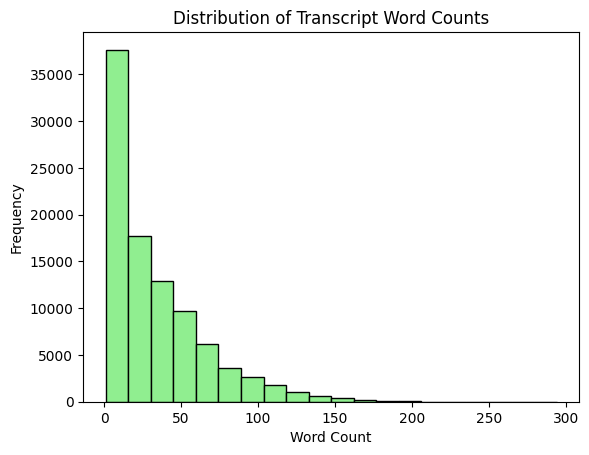

## Now viewing: **Top words in transcript**

### Top Words in Transcript

1. **go**: 185442

2. **le**: 152376

3. **e**: 118999

...

,type,transcript
105399,scripted,"Zwivhuya zwine matshudeni a TVET vha vha nazwo a si u wana nḓivho fhedzi, fhedzi hu na tshipiḓa tshine mutshudeni muṅwe muṅwe a tea u ita tsha mushumo u itela u tshenzhema vhupo ha mushumoni wa vhukuma u khwaṱhisedza uri vha na vhukoni phanḓa ha musi vha tshi ṱanganedza ndalukano dzavho, u ralo a tshi amba."
105400,scripted,"Vha ṱutshele zwa u kwama tshifhaṱuwo nga zwanḓa zwi re na tshika tshifhinga tshoṱhe. Arali vho zwi ita, kha vha vhone zwauri tsha u thoma vha ṱamba zwanḓa zwavho nga tshisibe nga vhuronwane."
105401,scripted,Muvhuso uyu na vhashumisani nawo u ḓo itela vhafumakadzi vha Afrika Tshipembe zwo teaho.
105402,scripted,Muvhuso u kha ḓi tou bva u anḓadza makumedzwa a khwiniso ya mulayo wa zwa fulufulu u itela u fhelisa ṱhoḓea ya ḽaisentsi kha zwiimiswa zwa u bveledza muḓagasi khathihi na u ṱuṱuwedza vhubindudzi kha thandela khulwane dza nḓisedzo ya muḓagasi hu u itela u engedza vhubveledzi vhuswa ha muḓagasi kha sisṱeme ya nḓisedzo ya muḓagasi.
105403,scripted,Ri ḓo anḓadza mulayo muswa ṋaṅwaha une wa ḓivhadza muhanga wa miholo ya zwiimiswa zwa muvhuso na khamphani dzi langwaho nga muvhuso u thivhela mbadelo dzo kalulaho dza miraḓo ya bodo na vhaofisiri vhahulwane.
105404,scripted,Wa u thoma ndi mulayotibe wa u khwinisa mulayo wa khwiniso ya mulayo wa zwa vhutshinyi vhutshinyi ha zwa vhudzekani na mafhungo a elanaho nazwo.
105405,scripted,Mabindu a tea u tikedza vhubindudzi vhu langwaho nga vhafumakadzi musi hu tshi rengwa thundu.
105406,scripted,Senthara iyi yo fhaṱwa zwenezwino nga vha Impande South Africa ḽine ḽa vha dzangano ḽa mveledziso nga kha thikhedzo ya Nelson Mandela Foundation.
105407,scripted,Musumbuluwo u swika ḽavhuṱanu vhukati ha 8h00 nga matsheloni na 4h30 nga masiari.
105408,scripted,Maitele a u ita khumbelo one aṋe o leludzwa nga mbudziso dzo vhudziswaho dzi a leluwa u pfeseswa nga tshi tshavha.


### Type: unscripted

,type,transcript
105460,unscripted,"Ndi nga thoma u ṱoḓulusa uri, ndi nga wana gai mbeu, dza u ṱavha maṱamaṱisi kana zwi ramba zwa maṱamaṱisi. Vhunzhi ha fhethu hune ndabva hone ri zwi wana nga tsini, so ndi ngaya nda ṱoḓulusa uri maṱamatisi a ṱavhiwa hani na uri a ṱhogomelisiwa hani, ngauri huna vhathu vhane vha vha vha tsini, vhane vha nga u thusa vhane vha vha na mabulasi a maṱamaṱisi ndi hone ndanga ya nda kona u wana tshenzhemo ya uri ndi ḓo ṱhogomela hani bulasi yanga. Zwisi fhelele hanefho ndi tshi fhedza ndo no kona u wana tshenzhemo kha vhathu vha tsini ndi hone ndi tshi nga ḓo kona uri ndi ye kha Department of Agricultural uri ndi kone u wana nḓivho na uri ndi kone u wana thuso ya masheleni, sa vhunga muhumbulo hu vha na bulasi ḽihulwane ḽa maṱamaṱisi fhedziha zwezwo zwi konadzea arali muthu a na bulasi ḽawe kana hu na hafho hune anga ṱavha hone maṱamaṱisi."
105461,unscripted,"Sa vhunga vha tshi dzula fhethu hune havho uri ndi kule, ndi nga to ṱoḓa uri ndi ye bulasini yavho sa hezwi hu nṋe nda ḓo vha ndi khou ṱoḓa thuso. Ya kuḓivhele kana u guda, uri zwifuwo zwi ṱhogomeliwa hani. Ndi nga vuwa nga matsheloni nda ya haningei nda i humbela thuso uri zwi nga konadzea na ndi uri ndi vhe ndi kho kona uri ndi ḓe ṱhaṅwe, vhege nthihi kana mbili uri ndi vhe ndi kho kona u guda arali hu na zwifuwo zwanga zwine nda kho ṱoḓa uri vho vha zwi ṱole, ndi nga zama kana ndi nga lwa nga nḓila dzoṱhe uri vha ḓe, fhedziha riḓo tea uri ri vha wanale tshiendedzi sa vhunga hu nṋe nda ḓo vha ndi khou ṱoḓa thuso."
105462,unscripted,"Ndi humbula u nga ri, maṋanga a kholomo avha a kho fhungudzeliwa uri musi dzi tshi lwa, uri musi dzi tshi khou tamba dzi si vhaisane. Kana u vhaisa vhathu, sa vhunga i vha i tshi kho ṱoḓa u ḓi lwela, arali i khou pfha i singo tsireledzea kha tshetsho tshifhinga."
105463,unscripted,"Nga nḓila ye nda zwi vhonisa ngayo, ndi soko pfhesesa u nga ri a masheleni ane vha khou a wana ndi maṱuku. Vhathu havha noni ndi madokotela vha dovha vha vha kho gudisa zwifuwo uri okay zwithu zwa so, a zwi itiwi sa vhunga tshifuwo na tsho, tshi tshi kona u thetshelesa tshi tshi kona u tevhedzela milayo. Ndi nga ha musi zwo gudisiwa, tshifuwo tshi tshi khou lwala before or before zwi tshi isiwa kha madokotela a na vhori ndi madokotela, ndi vhaongi vha zwifuwo. Vha thoma vha ṱhogomela ndi ngazwo ndi tshi ndi tshi pfesesa u nga ri havha vhathu ndivhuwo ine vha khou fhiwa yone ndi ṱhukhu vha deserve or vho faneliwa nga tshelede ine ya vha uri ndi tshelede nnzhi."
105464,unscripted,"Tshaka dza waini dzine nda ḓivha dzone, thaidzo ndi yo uri athi dzi ḓivhi nga Tshivenḓa uri dzi vhidziwa hani mara ndi ḓo thoma nga ine nda i funesa ine ya vha uri ndi [?], then [?], ende then [?], ende then [?] ndi dzone waini dzine nda ḓivha dzone ndi sa ḓivhi, nga tshivenḓa nga tshivenḓa u amba ngoho thi thu vhuya nda zwipfha vho nga tshivenḓa."
105465,unscripted,"Sa vhunga ndi sokou pfha unga athi thikho u pfhesesa mbudziso, ya [pause] vusuludzwa ha mavu. Fhedziha nga nḓivho ṱhukhuṱhukhu ine nda vha nayo nga ha u, vhuedzedziwa ha mavu kha vhaṋe vha [pause] ndi soko pfhesesa u nga ndi zwone zwithu zwine, zwa kho thusa Afrika Tshipembe uri ḽi kone uvha vhuimoni haḽo. Ḽi kone u vha Afrika Tshipembe ḽa mulovha ḽine ḽa ḽo tea u vha ḽone, fhedzi ha zwi fhedza zwa thusa na kha vhathu vhane vha balelwa u wana mishumo, na u ita mishumo sa vhunga sa izwi, mavu arali avha o vhuedziseliwa kha nṋe muṋe wayo. Zwi sumba uri nṋe ndi ḓo kona u hira vhathu vha kone u shuma."
105466,unscripted,"Mbudzi i a dzi ṱoḓi naho muthu a tshi tou vha na dzharaṱa ṱhukhu, muthu u a kona u fuwa mbudzi ende mbudzi dzi [pause] dzi a kona u ḓisa mafhi muḓini. Ende zwi tshi ḓa kha u zwala mbudzi dzi ya zwala nga maanḓa, lune zwi fhedza zwi kho engedza mbalo ya ya mbudzi, [pause] dzene vha tea u vha nadzo. Zwitshiḓa kha tshelede mbudzi dzi [pause] a dzi to rengiswa nga thengo khulu u fana na dzi nngu, kholomo ende dzi a kona u langea, dzi ḽa mahatsi zwine ndi zwinwe zwithu zwine zwivha zwi muḓin

### Number of empty or null transcripts: 0

/var/folders/fp/sw4jgfl52v55cy177x9pw_yh0000gn/T/ipykernel_1576/3764910346.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['transcript_word_count'] = df_filtered['transcript'].apply(lambda x: len(str(x).split()))


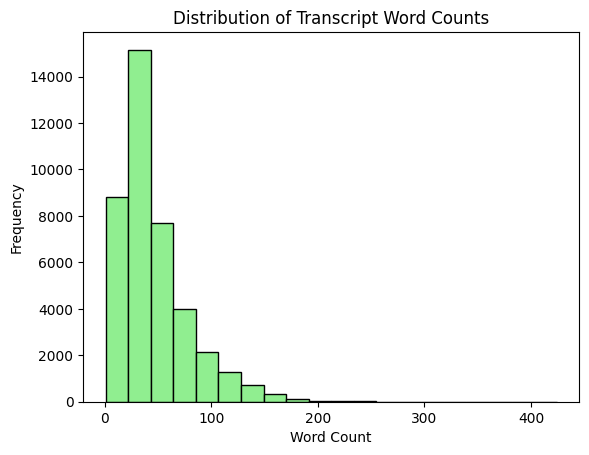

## Now viewing: **Top words in transcript**

### Top Words in Transcript

1. **u**: 98404

2. **vha**: 91568

3. **na**: 56316

...

16. **ha**: 17351

17. **wa**: 16027

18. **hu**: 15484

19. **vhathu**: 14678

20. **kana**: 13844

In [17]:
for language, code in list(lang_dict.items())[:N]:
    df_filtered = df[df['language'] == code]

    display(Markdown(f"## Now viewing: **Top words in {language} ({code})**"))

    pd.set_option("display.max_rows", None)
    pd.set_option("display.max_colwidth", None)

    for category in sorted(df_filtered['type'].dropna().unique()):
        subset = df_filtered[df_filtered['type'] == category][['type', 'transcript']].head(10)
        display(Markdown(f"### Type: {category}"))
        display(subset)

    #count none or empty transcripts
    empty_transcripts = df_filtered['transcript'].isnull().sum() + (df_filtered['transcript'].str.strip() == '').sum()
    display(Markdown(f"### Number of empty or null transcripts: {empty_transcripts}"))


    df_filtered['transcript_word_count'] = df_filtered['transcript'].apply(lambda x: len(str(x).split()))
    plt.hist(df_filtered['transcript_word_count'], bins=20, color="lightgreen", edgecolor="black")
    plt.title("Distribution of Transcript Word Counts")
    plt.xlabel("Word Count")
    plt.ylabel("Frequency")
    plt.show()


    display(Markdown(f"## Now viewing: **Top words in transcript**"))
    from collections import Counter
    all_words = ' '.join(df_filtered['transcript'].dropna()).lower().split()
    word_counts = Counter(all_words)
    top_words = word_counts.most_common(20)
    display(Markdown(f"### Top Words in Transcript"))
    for i, (word, count) in enumerate(top_words, start=1):
        display(Markdown(f"{i}. **{word}**: {count}"))

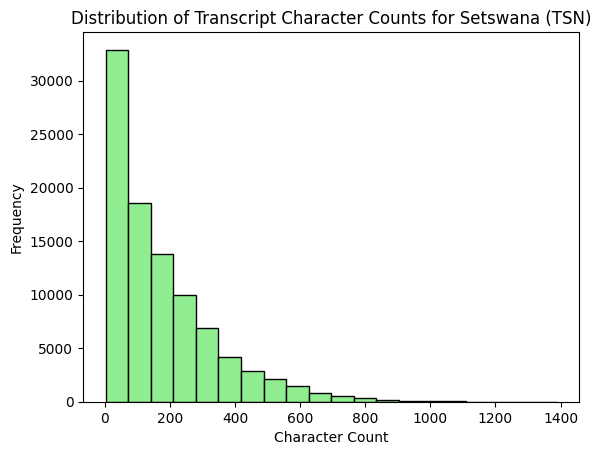

## Now viewing: **Top characters in transcript for Setswana (TSN)**

### Number of Unique Characters in Transcript: 54

### Top 20 Characters in Transcript

1. **a**: 2086695

2. **e**: 1653029

...

16. **w**: 266079

17. **y**: 161368

18. **p**: 156674

19. **.**: 132733

20. **f**: 130275

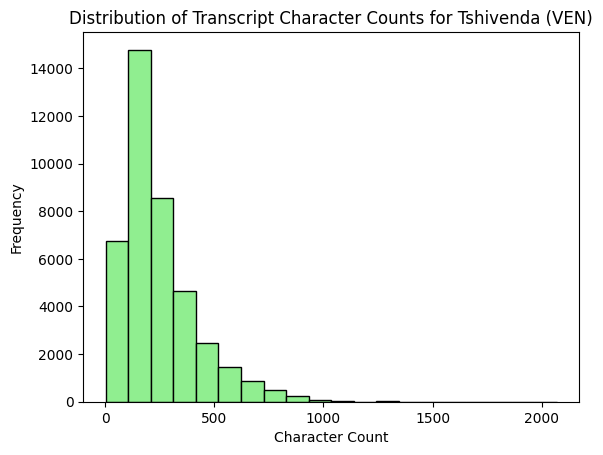

## Now viewing: **Top characters in transcript for Tshivenda (VEN)**

### Number of Unique Characters in Transcript: 52

### Top 20 Characters in Transcript

1. **a**: 1308638

2. **h**: 821741

...

16. **k**: 194541

17. **g**: 154572

18. **r**: 138719

19. **y**: 95834

20. **f**: 87069

In [18]:
for language, code in list(lang_dict.items())[:N]:
    df_filtered = df[df['language'] == code]

    df_filtered = df_filtered.copy()
    df_filtered['transcript_char_count'] = df_filtered['transcript'].apply(lambda x: len(str(x)))

    plt.hist(df_filtered['transcript_char_count'], bins=20, color="lightgreen", edgecolor="black")
    plt.title(f"Distribution of Transcript Character Counts for {language} ({code})")
    plt.xlabel("Character Count")
    plt.ylabel("Frequency")
    plt.show()

    display(Markdown(f"## Now viewing: **Top characters in transcript for {language} ({code})**"))
    from collections import Counter
    all_chars = ''.join(df_filtered['transcript'].dropna()).lower()
    filtered_chars = [c for c in all_chars if not c.isspace()]
    char_counts = Counter(filtered_chars)
    top_chars = char_counts.most_common(20)

    number_of_unique_chars = len(char_counts)
    display(Markdown(f"### Number of Unique Characters in Transcript: {number_of_unique_chars}"))


    display(Markdown(f"### Top 20 Characters in Transcript"))
    for i, (char, count) in enumerate(top_chars, start=1):
        display(Markdown(f"{i}. **{char}**: {count}"))

# NCHLT Analysis (Tshivenda)

In [19]:
# Tshivenda only - Setswana/Sepedi are handled by their own sub-studies
nchlt_df = pd.read_csv("../dataset/dsfsi-anv/nchlt/multilingual-nchlt-dataset_ven.csv")
nchlt_df.shape

(49748, 12)

In [20]:
nchlt_df.head(5)

,filename,speaker,text,language,language_code,gender,audio_sampling_rate,audio_num_samples,audio_duration_s,audio_size_bytes,audio_num_channels,split
0,nchlt_ven_001m_0005.wav,ven_001,afrika tshipembe arali khumbelo vha,Tshivenda,ven,male,16000,65280,4.08,261120,1,train
1,nchlt_ven_001m_0013.wav,ven_001,musi khumbelo yavho i tshi,Tshivenda,ven,male,16000,51840,3.24,207360,1,train
2,nchlt_ven_001m_0011.wav,ven_001,ya kholomo dzine dzi nga,Tshivenda,ven,male,16000,51840,3.24,207360,1,train
3,nchlt_ven_001m_0016.wav,ven_001,ngo tea u thusa muvhuso,Tshivenda,ven,male,16000,49920,3.12,199680,1,train
4,nchlt_ven_001m_0008.wav,ven_001,na mufarisa mudzulatshidulo vha do,Tshivenda,ven,male,16000,69120,4.32,276480,1,train


In [21]:
nchlt_df.isnull().sum()

filename               0
speaker                0
text                   0
language               0
language_code          0
gender                 0
audio_sampling_rate    0
audio_num_samples      0
audio_duration_s       0
audio_size_bytes       0
audio_num_channels     0
split                  0
dtype: int64

## Now viewing Tshivenda (VEN): **split**

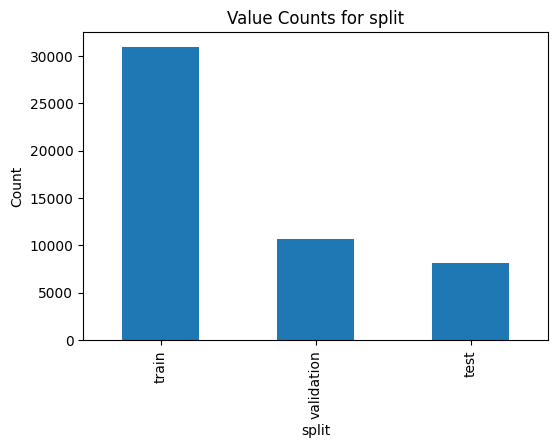

## Now viewing Tshivenda (VEN): **gender**

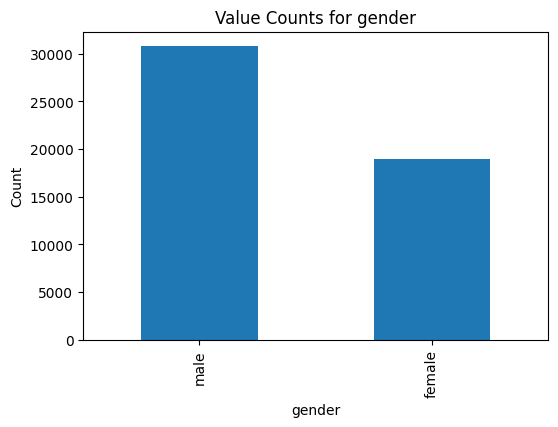

## Now viewing Tshivenda (VEN): **audio_sampling_rate**

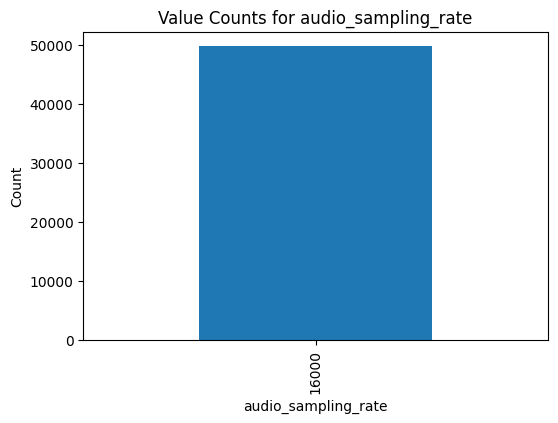

## Now viewing Tshivenda (VEN): **audio_num_channels**

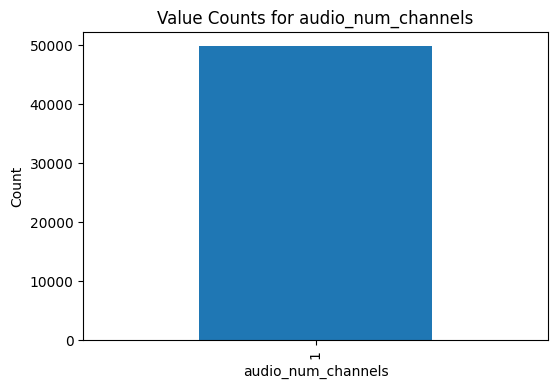

In [22]:
# Tshivenda only - Setswana/Sepedi are handled by their own sub-studies
for language, code in [("Tshivenda", "VEN")]:
    nchlt_filtered = nchlt_df[nchlt_df['language_code'] == code.lower()]
    display_coloumns = ['split','gender','audio_sampling_rate','audio_num_channels']
    for col in nchlt_filtered[display_coloumns].columns:
        # Use display() combined with Markdown()
        display(Markdown(f"## Now viewing {language} ({code}): **{col}**"))

        plt.figure(figsize=(6, 4))
        nchlt_filtered[col].value_counts().plot(kind="bar")
        plt.title(f"Value Counts for {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()

## Now viewing: **audio_duration_s**

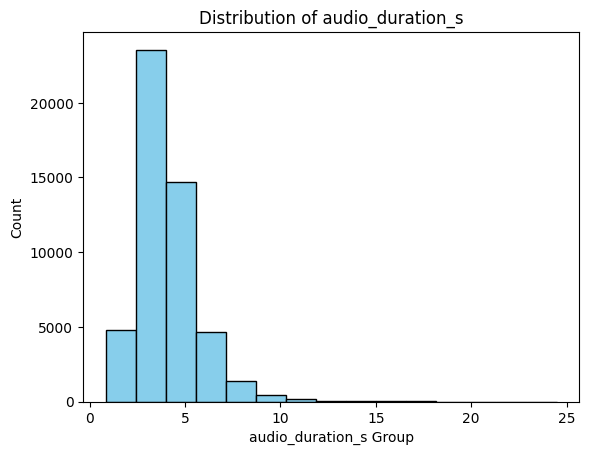

count    49748.000000
mean         4.072517
std          1.552830
min          0.840000
25%          3.000000
50%          3.720000
75%          4.800000
max         24.480000
Name: audio_duration_s, dtype: float64

## Now viewing: **audio_size_bytes**

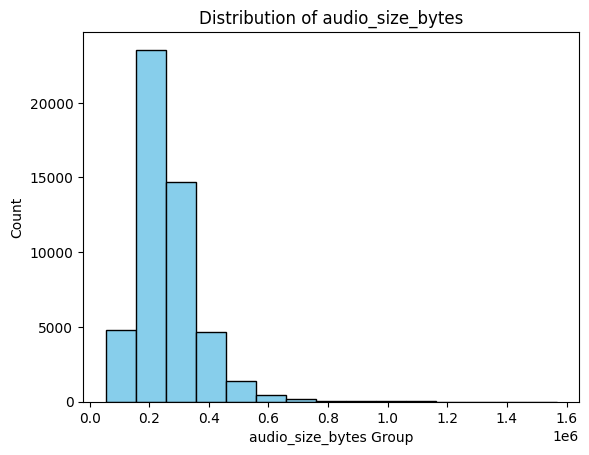

count    4.974800e+04
mean     2.606411e+05
std      9.938112e+04
min      5.376000e+04
25%      1.920000e+05
50%      2.380800e+05
75%      3.072000e+05
max      1.566720e+06
Name: audio_size_bytes, dtype: float64

## Now viewing: **audio_num_samples**

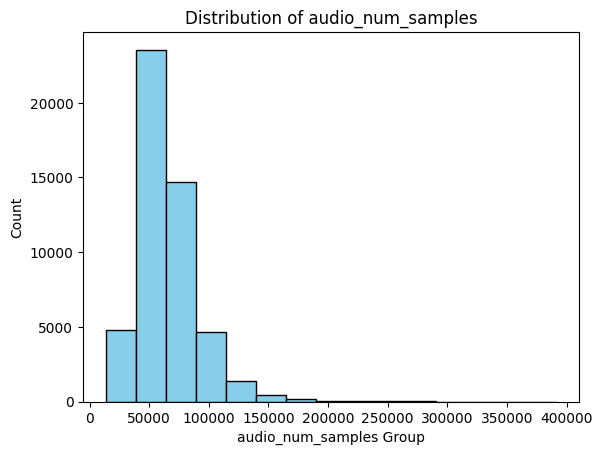

count     49748.000000
mean      65160.279810
std       24845.279913
min       13440.000000
25%       48000.000000
50%       59520.000000
75%       76800.000000
max      391680.000000
Name: audio_num_samples, dtype: float64

In [23]:
# Tshivenda only - Setswana/Sepedi are handled by their own sub-studies
for language, code in [("Tshivenda", "VEN")]:
    nchlt_filtered = nchlt_df[nchlt_df['language_code'] == code.lower()]
    display_coloumns = ['audio_duration_s','audio_size_bytes','audio_num_samples']
    for col in nchlt_filtered[display_coloumns].columns:

        display(Markdown(f"## Now viewing: **{col}**"))

        # Pass the data array/series directly
        plt.hist(nchlt_filtered[col], bins=15, color="skyblue", edgecolor="black")

        # Adding labels
        plt.title(f"Distribution of {col}")
        plt.xlabel(f"{col} Group")
        plt.ylabel("Count")

        # Display the plot
        plt.show()

        display(nchlt_filtered[col].describe())

## Now viewing: **Speaker balance for Tshivenda (VEN)**

### Number of Unique Speakers: 208

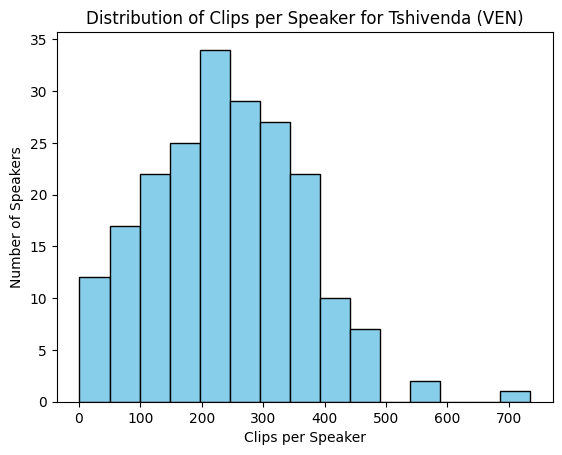

count    208.000000
mean     239.173077
std      123.292311
min        1.000000
25%      150.000000
50%      237.000000
75%      320.500000
max      735.000000
Name: count, dtype: float64

In [24]:
# Tshivenda only - Setswana/Sepedi are handled by their own sub-studies
for language, code in [("Tshivenda", "VEN")]:
    nchlt_filtered = nchlt_df[nchlt_df['language_code'] == code.lower()]

    display(Markdown(f"## Now viewing: **Speaker balance for {language} ({code})**"))

    number_of_unique_speakers = nchlt_filtered['speaker'].nunique()
    display(Markdown(f"### Number of Unique Speakers: {number_of_unique_speakers}"))

    plt.hist(nchlt_filtered['speaker'].value_counts(), bins=15, color="skyblue", edgecolor="black")
    plt.title(f"Distribution of Clips per Speaker for {language} ({code})")
    plt.xlabel("Clips per Speaker")
    plt.ylabel("Number of Speakers")
    plt.show()

    display(nchlt_filtered['speaker'].value_counts().describe())

## Now viewing: **Text checks for Tshivenda (VEN)**

### Number of empty or null transcripts: 0

### Number of duplicate filenames: 0

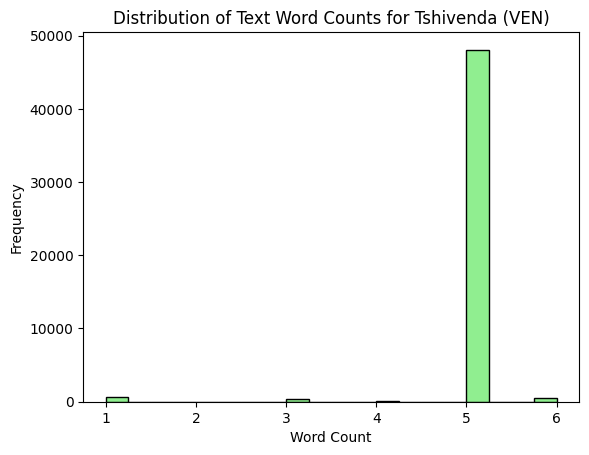

In [25]:
# Tshivenda only - Setswana/Sepedi are handled by their own sub-studies
for language, code in [("Tshivenda", "VEN")]:
    nchlt_filtered = nchlt_df[nchlt_df['language_code'] == code.lower()]

    display(Markdown(f"## Now viewing: **Text checks for {language} ({code})**"))

    #count none or empty transcripts
    empty_transcripts = nchlt_filtered['text'].isnull().sum() + (nchlt_filtered['text'].str.strip() == '').sum()
    display(Markdown(f"### Number of empty or null transcripts: {empty_transcripts}"))

    #count duplicate filenames
    duplicate_filenames = nchlt_filtered['filename'].duplicated().sum()
    display(Markdown(f"### Number of duplicate filenames: {duplicate_filenames}"))

    nchlt_filtered = nchlt_filtered.copy()
    nchlt_filtered['text_word_count'] = nchlt_filtered['text'].apply(lambda x: len(str(x).split()))
    plt.hist(nchlt_filtered['text_word_count'], bins=20, color="lightgreen", edgecolor="black")
    plt.title(f"Distribution of Text Word Counts for {language} ({code})")
    plt.xlabel("Word Count")
    plt.ylabel("Frequency")
    plt.show()

In [26]:
# Tshivenda only - Setswana/Sepedi are handled by their own sub-studies
for language, code in [("Tshivenda", "VEN")]:
    nchlt_filtered = nchlt_df[nchlt_df['language_code'] == code.lower()]

    display(Markdown(f"## Now viewing: **Data quality checks for {language} ({code})**"))

    clips_under_1s = (nchlt_filtered['audio_duration_s'] < 1).sum()
    clips_under_5s = (nchlt_filtered['audio_duration_s'] < 5).sum()
    clips_over_30s = (nchlt_filtered['audio_duration_s'] > 30).sum()
    display(Markdown(f"### Clips < 1s: {clips_under_1s} | Clips < 5s: {clips_under_5s} | Clips > 30s: {clips_over_30s}"))

    speakers_in_multiple_splits = (nchlt_filtered.groupby('speaker')['split'].nunique() > 1).sum()
    display(Markdown(f"### Speakers appearing in more than one split: {speakers_in_multiple_splits}"))

    all_chars = sorted(set(''.join(nchlt_filtered['text'].dropna().astype(str)).lower()))
    display(Markdown(f"### Number of Unique Characters in Text: {len(all_chars)}"))
    display(Markdown(f"### Character set: `{''.join(all_chars)}`"))

## Now viewing: **Data quality checks for Tshivenda (VEN)**

### Clips < 1s: 4 | Clips < 5s: 38859 | Clips > 30s: 0

### Speakers appearing in more than one split: 0

### Number of Unique Characters in Text: 32

### Character set: ` abcdefghijklmnopqrstuvwxyzḓḽṅṋṱ`

# Tshivenda EDA Findings & Filtering Rules

**NCHLT (ven): 49,748 clips, 56.3 hrs**
- Already 16 kHz mono throughout - no resampling needed.
- Splits: 30,984 train / 10,617 validation / 8,147 test. No speaker appears in more than one split (no leakage).
- 0 empty/null transcripts, 0 duplicate filenames. 295 duplicate (speaker, text) pairs = same prompt re-read, harmless.
- 208 speakers, median 237 clips each; gender skews male (30,781 vs 18,967) - worth reporting, not fixable.
- Durations: median 3.7 s, max 24.5 s, only 4 clips < 1 s. No VAD segmentation needed (nothing exceeds 30 s).
- Character set is clean: a-z, space, plus Tshivenda diacritics ḓ ḽ ṅ ṋ ṱ (32 chars total).

**ANV / Swivuriso (ven): 40,359 clips, 238.4 hrs**
- All 48 kHz mono - **must resample to 16 kHz** for Wav2Vec2/Whisper.
- Splits: 36,344 train / 2,360 dev / 1,655 dev_test. No recorder appears in more than one split.
- 0 empty/null transcripts, 0 duplicate audio_ids.
- Durations: median 17.7 s, max 180.7 s. **8,028 clips (20%) exceed 30 s** - these need VAD segmentation into 5-30 s windows. 1,171 clips < 5 s (keep; still usable). 0 clips < 1 s.
- SNR: minimum is 30 dB - nothing is noisy enough to drop. No SNR filter needed.
- Character set (54 chars) includes digits 0-9, punctuation (! " ' , - . ?), brackets, backslash, and a non-breaking space (\xa0) - **transcripts need normalisation before CTC tokenizer building**.

**Filtering / preprocessing rules to carry forward:**
1. NCHLT: drop the 4 clips < 1 s; use as-is otherwise (already 16 kHz mono, already short clips).
2. ANV: resample 48 kHz to 16 kHz; VAD-segment the 8,028 clips > 30 s into 5-30 s windows; drop nothing on SNR or transcripts.
3. Text normalisation (both corpora): lowercase; strip punctuation and digits. Note: the fine-tuning notebook's CHARS_TO_IGNORE regex does not yet cover backslash or the non-breaking space (\xa0) found in ANV transcripts - extend it.
4. CTC tokenizer vocabulary must include the five Tshivenda diacritic characters: ḓ ḽ ṅ ṋ ṱ.
